In [1]:
import numpy as np
import pandas as pd

import pathlib
import random
import copy
import numpy as np
import torch


import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import yaml
import argparse
from data.data_loader import load_eeg_data, get_sliding_window_data, create_dataloader
import os
import mne
from tqdm import tqdm
import pandas as pd

from models.s4net import S4PatchedFinalNet,TrunkNet, HeadNet
import gc

import itertools
from scipy.stats import ttest_ind

import sklearn.model_selection
import sklearn.linear_model
import scipy.stats
import seaborn as sns

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.


In [2]:
CFG_YAML = """
wandb:
 key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model:
dataset:
 data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
 #file_name: subject_{:03d}_preprocessed_combined_py.fif
 file_name: subject_{:03d}_preprocessed_combined_py.fif
 exclude_timepoints: 100
 subject_index: 1
 test_subject_indices: [1,2,13,24,26,27,29,34,35,41, 42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88, 92,102]
 #test_subject_indices: [2]
training:
 training_start_len: 100
 pretrain_epochs: 100
 pretrain_lr: 0.0001
 val_window_len: 1
 epochs_per_window: 10
 num_warmup_epochs: 5
 num_epochs: 800
 slide_step: 1
 num_warmup_epochs_per_window: 0
 lr: 0.005 #maybe change back to 0.0001
 nll_beta: 0.001
 num_warmup_epochs: 0
 batch_size: 50 #better to use 50
 random_seed: 42
 precision: bf16
 kde_lambda: 0.5
 finetune_entire_model: true # Set to true to finetune the entire model, false for transformer only
exp_name: S4_S4EEGNet_ema
"""


def load_config():
    cfg = OmegaConf.create(yaml.safe_load(CFG_YAML))
    cfg.exp_name = f"{cfg.exp_name}_subject_{cfg.dataset.subject_index}"
    return cfg

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--update_conf", nargs="*", help="Updates to the configuration in the form of key=value pairs", default=[])
    parser.add_argument("-f", "--fff", help="A dummy argument to handle IPython's default argument", default="1")
    return parser.parse_args()

def update_config(cfg, cli_args):
    for update in cli_args.update_conf:
        key, value = update.split("=")
        try:
            value = eval(value)
        except:
            pass
        OmegaConf.update(cfg, key, value, force_add=True)
    cfg.exp_name = cfg.exp_name + "_" + "_".join(cli_args.update_conf)
    print(OmegaConf.to_yaml(cfg))
    return cfg


def save_config(cfg):
    os.makedirs("conf/sweeps", exist_ok=True)
    os.makedirs("exp/withinsubs", exist_ok=True)
    with open(f"conf/sweeps/withinsubs_{cfg.exp_name}.yaml", "w") as f:
        f.write(OmegaConf.to_yaml(cfg))


In [3]:
coherence_data = np.load("results_coherence_all_subjects.npy", allow_pickle=True).item()


In [4]:
def n_sig_correlations(data, bonferrroni=3600, significance_level=0.05):
    # for each subject count the number of significant correlations and divide by 3600 (the number of tests)
    # output should be a significant correlation ratio for each subject and frequency band
    # also note that sor far we were very lenient with the p-value threshold using 0.05/60, but realistically for paired channels we need to use 0.05/3600
    n_sig_correlations = {}
    for subject in data.keys():
        n_sig_correlations[subject] = {}
        for freq in data[subject].keys():
            n_sig_correlations[subject][freq] = 0
            for pair, stats in data[subject][freq].items():

                if stats["pval"] < (significance_level/bonferrroni):
                    n_sig_correlations[subject][freq] += 1
    

    return n_sig_correlations   

In [5]:
n_sig_coherence = n_sig_correlations(coherence_data)

In [6]:
n_sig_coherence

{1: {'delta': 0, 'theta': 6, 'alpha': 0, 'beta': 0, 'gamma': 8},
 2: {'delta': 0, 'theta': 2, 'alpha': 100, 'beta': 20, 'gamma': 252},
 13: {'delta': 0, 'theta': 0, 'alpha': 0, 'beta': 0, 'gamma': 62},
 24: {'delta': 616, 'theta': 430, 'alpha': 248, 'beta': 368, 'gamma': 402},
 26: {'delta': 18, 'theta': 0, 'alpha': 0, 'beta': 0, 'gamma': 4},
 27: {'delta': 0, 'theta': 0, 'alpha': 0, 'beta': 0, 'gamma': 0},
 29: {'delta': 0, 'theta': 0, 'alpha': 1, 'beta': 0, 'gamma': 209},
 34: {'delta': 140, 'theta': 93, 'alpha': 3, 'beta': 0, 'gamma': 251},
 35: {'delta': 0, 'theta': 0, 'alpha': 0, 'beta': 0, 'gamma': 56},
 41: {'delta': 5, 'theta': 19, 'alpha': 32, 'beta': 38, 'gamma': 72},
 42: {'delta': 0, 'theta': 0, 'alpha': 0, 'beta': 1, 'gamma': 39},
 43: {'delta': 3, 'theta': 171, 'alpha': 364, 'beta': 445, 'gamma': 1163},
 45: {'delta': 0, 'theta': 0, 'alpha': 0, 'beta': 0, 'gamma': 18},
 46: {'delta': 0, 'theta': 0, 'alpha': 0, 'beta': 0, 'gamma': 216},
 47: {'delta': 29, 'theta': 1, 'alph

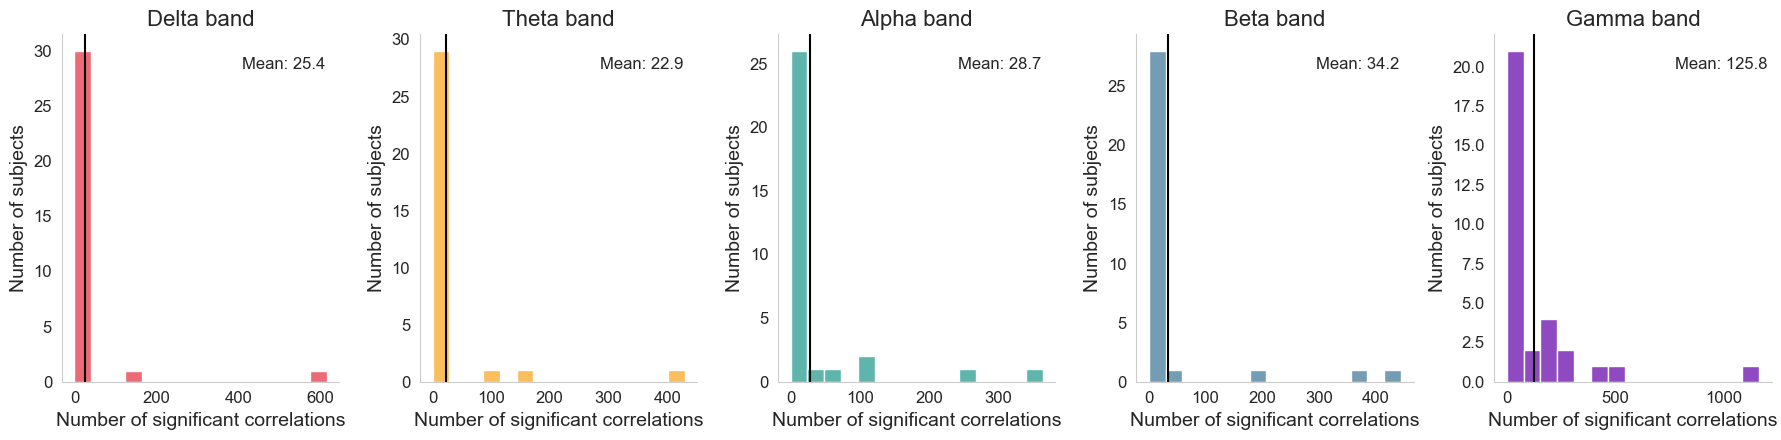

In [143]:
fig = plot_n_sig_correlations(n_sig_coherence)
fig.suptitle("Number of significant correlations for coherence", y=1.1, fontsize=20)
fig.savefig("coherence_sig_correlations.png", bbox_inches='tight', dpi=300)



In [139]:
def plot_n_sig_correlations(data):
    sns.set_style("whitegrid")
    
    frequency_bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
    colors = {
        'delta': '#E63946',  # Crimson red
        'theta': '#F9A826',  # Orange
        'alpha': '#2A9D8F',  # Teal
        'beta':  '#457B9D',  # Blue
        'gamma': '#6A0DAD',  # Purple
    }
    
    fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))
    
    for i, freq in enumerate(frequency_bands):
        # Extract values for this frequency band
        subjects = list(data.keys())
        values = [data[subject][freq] for subject in subjects]
        
        # Plot histogram with seaborn's histplot for better aesthetics
        sns.histplot(values, bins=15, color=colors[freq], kde=False, ax=axes[i])
        axes[i].set_title(f"{freq.capitalize()} band", fontsize=16)
        axes[i].set_xlabel("Number of significant correlations", fontsize=14)
        axes[i].set_ylabel("Number of subjects", fontsize=14)
        
        # Remove grid lines
        axes[i].grid(False)
        
        # Remove top and right spines
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        
        # Add mean line with annotation
        mean_val = np.mean(values)
        axes[i].axvline(mean_val, color='black', linestyle='-', linewidth=1.5)
        axes[i].text(0.65, 0.9, f"Mean: {mean_val:.1f}", transform=axes[i].transAxes, 
                    fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        # Increase tick label font sizes
        axes[i].tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    plt.show()
    return fig

In [106]:
import seaborn as sns

def plot_n_sig_correlations_multiple(data, features=["pli", "wpli", "icoh"]):
    # notice that icoh is named wrong and is in reality iplv
    sns.set_style("whitegrid")
    
    frequency_bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
    colors = {
        'delta': '#E63946',  # Crimson red
        'theta': '#F9A826',  # Orange
        'alpha': '#2A9D8F',  # Teal
        'beta':  '#457B9D',  # Blue
        'gamma': '#6A0DAD',  # Purple
    }
    
    fig = plt.figure(figsize=(18, 8))
    fig.suptitle('Number of significant correlations for pli and wpli', y=1.1, fontsize=20)
    subfigs = fig.subfigures(nrows=len(features), ncols=1, wspace=0.1, hspace=0.4) 
    
    for j, subfig in zip(range(len(features)), subfigs):
        title = f"Significant correlations for iplv" if j==2 else f"Significant correlations for {features[j]}"
        subfig.suptitle(title, y=1.1, fontsize=18)
        axs = subfig.subplots(nrows=1, ncols=len(frequency_bands), sharex=True, sharey=True)
        
        for ax, freq in zip(axs, frequency_bands):
            # Extract values for this frequency band
            subjects = list(data[j].keys())
            values = [data[j][subject][freq] for subject in subjects]
            
            # Plot histogram with seaborn's histplot for better aesthetics
            sns.histplot(values, bins=15, color=colors[freq], kde=False, ax=ax)
            ax.set_title(f"{freq.capitalize()} band", fontsize=16)
            ax.set_xlabel("Significant correlations", fontsize=14)
            ax.set_ylabel("Number of subjects", fontsize=14)
            
            # Remove all grid lines
            ax.grid(False)
            
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Increase tick label font sizes
            ax.tick_params(axis='both', which='major', labelsize=12)
            
            # Add mean line with annotation
            mean_val = np.mean(values)
            ax.axvline(mean_val, color='black', linestyle='-', linewidth=1.5)
            ax.text(0.65, 0.9, f"Mean: {mean_val:.1f}", transform=ax.transAxes, 
                   fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    plt.tight_layout()
    plt.show()
    return fig


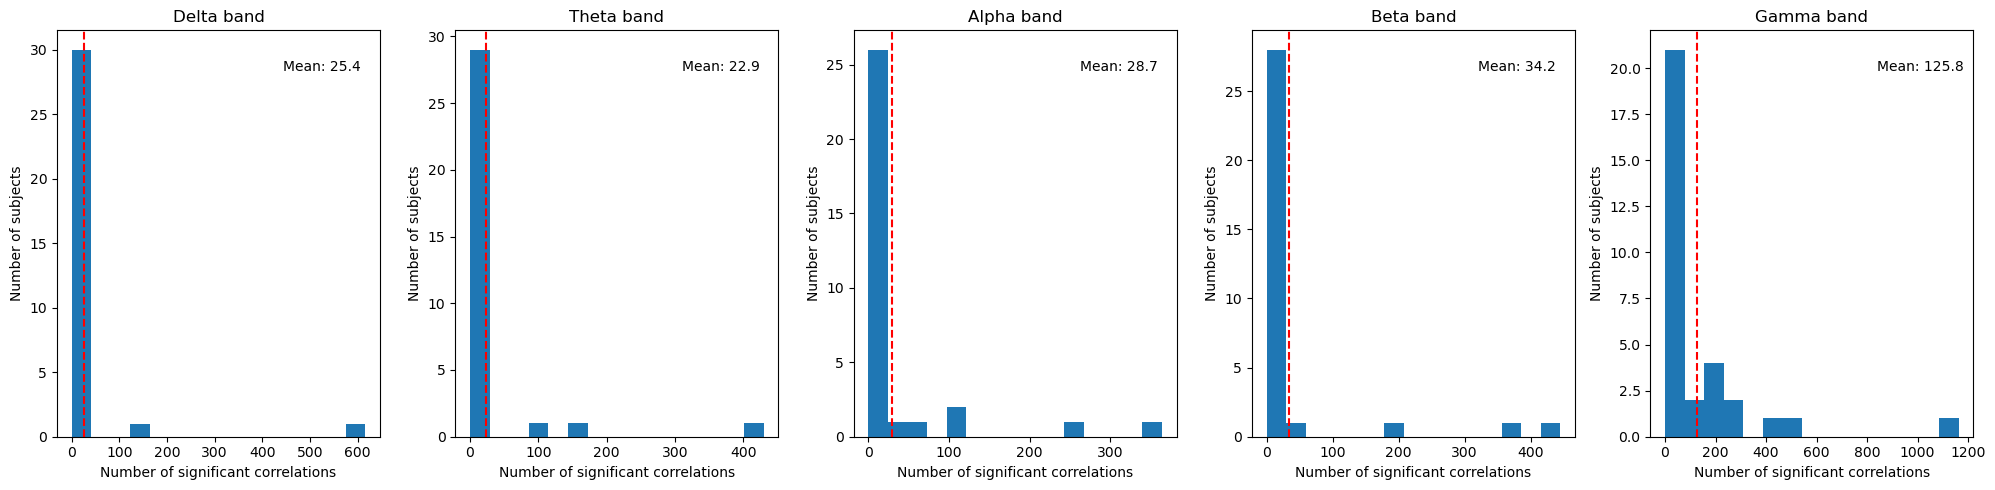

In [ ]:
# interpret the results with care. For each of the 32 subjects there can be 3600 significant correlations. -> In short results are abysmal
plot_n_sig_correlations(n_sig_coherence)

In [10]:
def load_connectivity_data(concept="pli"):
    dir = f"/home/marco/Documents/GitHub/tms_eeg_decoding/concepts_frequency/results/{concept}"

    all_data = {}

    cfg = load_config()
    for subject_index in cfg.dataset.test_subject_indices:
        if subject_index in [92,102]:
            continue
        all_data[subject_index] = {}
        file_name = f"subject_{subject_index}_{concept}.npy"
        path = os.path.join(dir, file_name)
        all_data[subject_index] = np.load(path, allow_pickle=True).item()

    

    # this function loads results of pli,wpli, icoh for all subje
    return all_data

In [11]:
pli_data = load_connectivity_data("pli")
wpli_data = load_connectivity_data("wpli")
icoh_data = load_connectivity_data("icoh")

In [13]:
n_sig_pli = n_sig_correlations(pli_data)
n_sig_wpli = n_sig_correlations(wpli_data)
n_sig_icoh = n_sig_correlations(icoh_data)

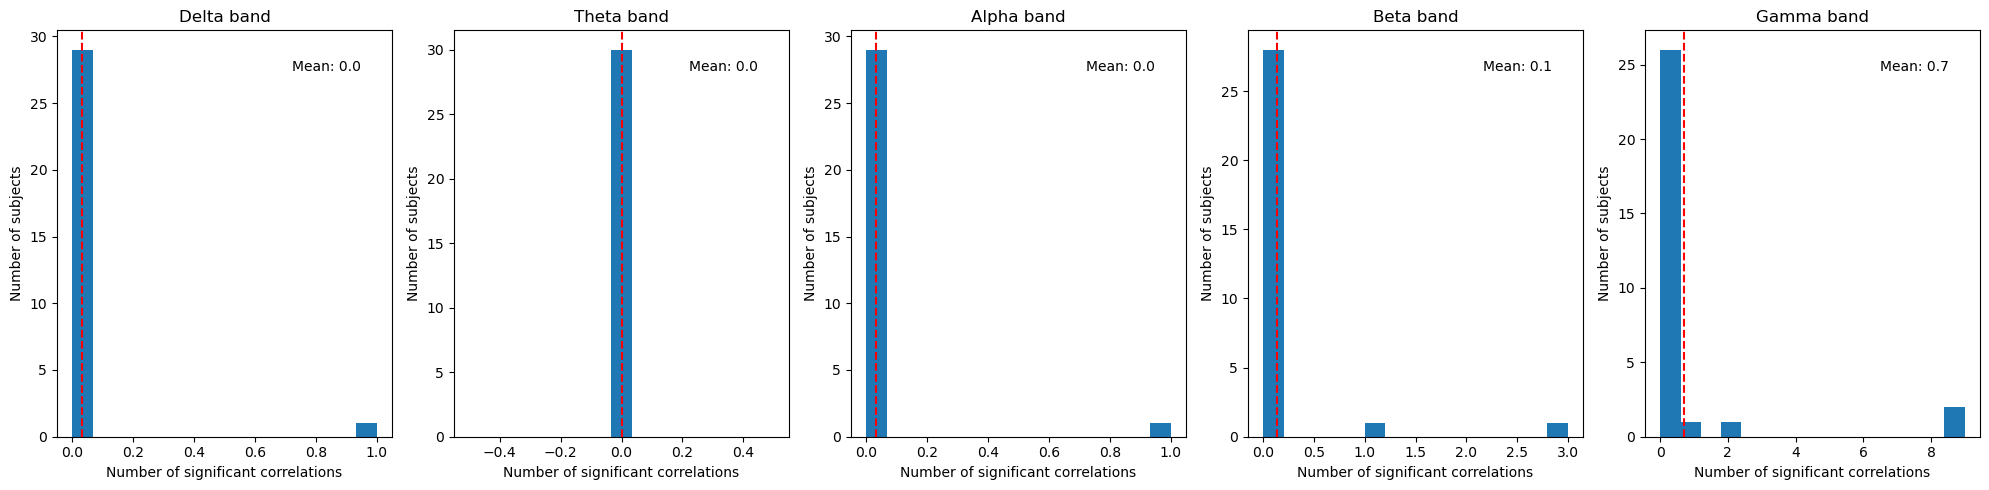

In [49]:
plot_n_sig_correlations(n_sig_pli)

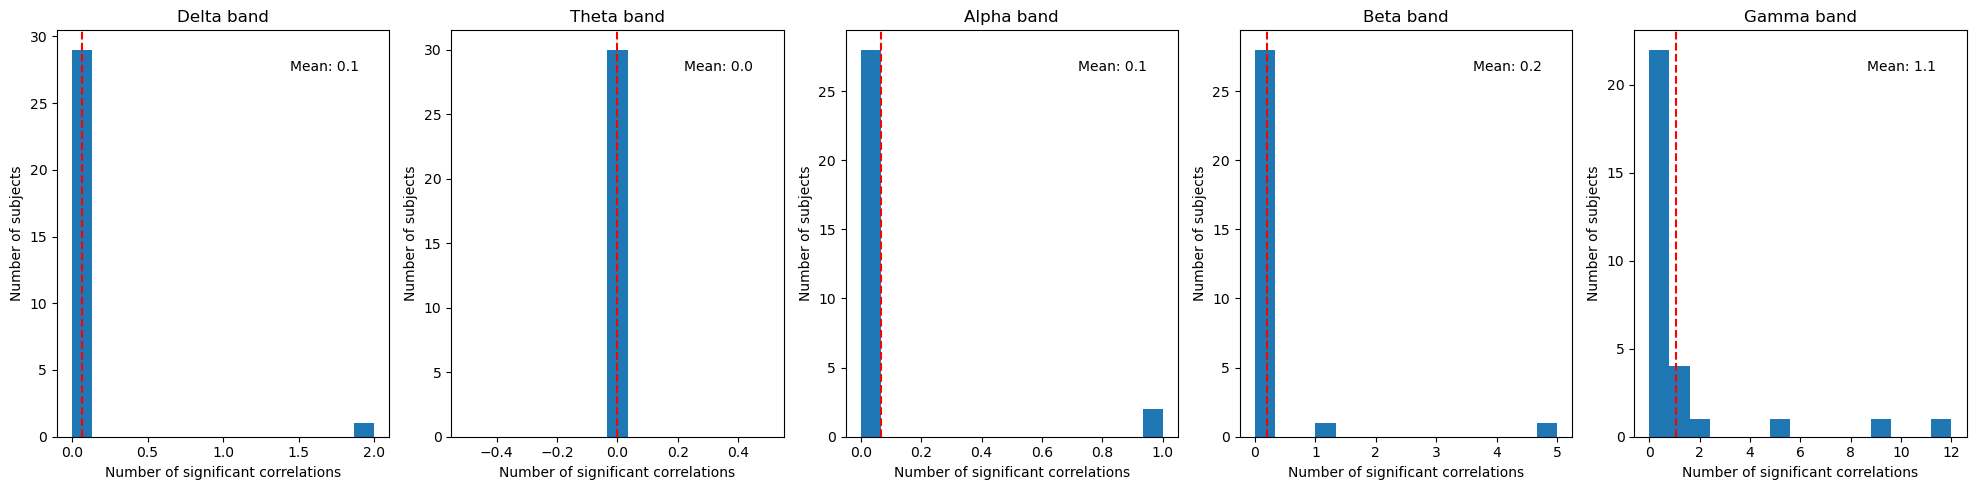

In [50]:
plot_n_sig_correlations(n_sig_wpli)

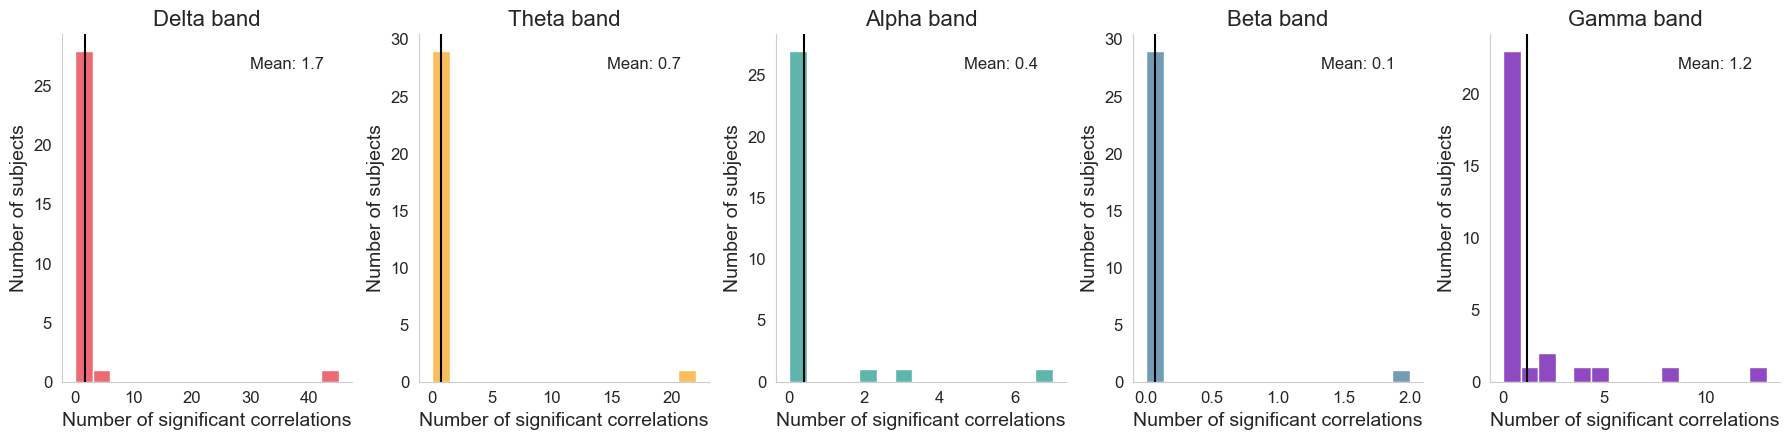

In [140]:
fig = plot_n_sig_correlations(n_sig_icoh)
fig.suptitle("Number of significant correlations for iplv", y=1.1, fontsize=20)
fig.savefig("iplv_sig_correlations.png", bbox_inches='tight', dpi=300)

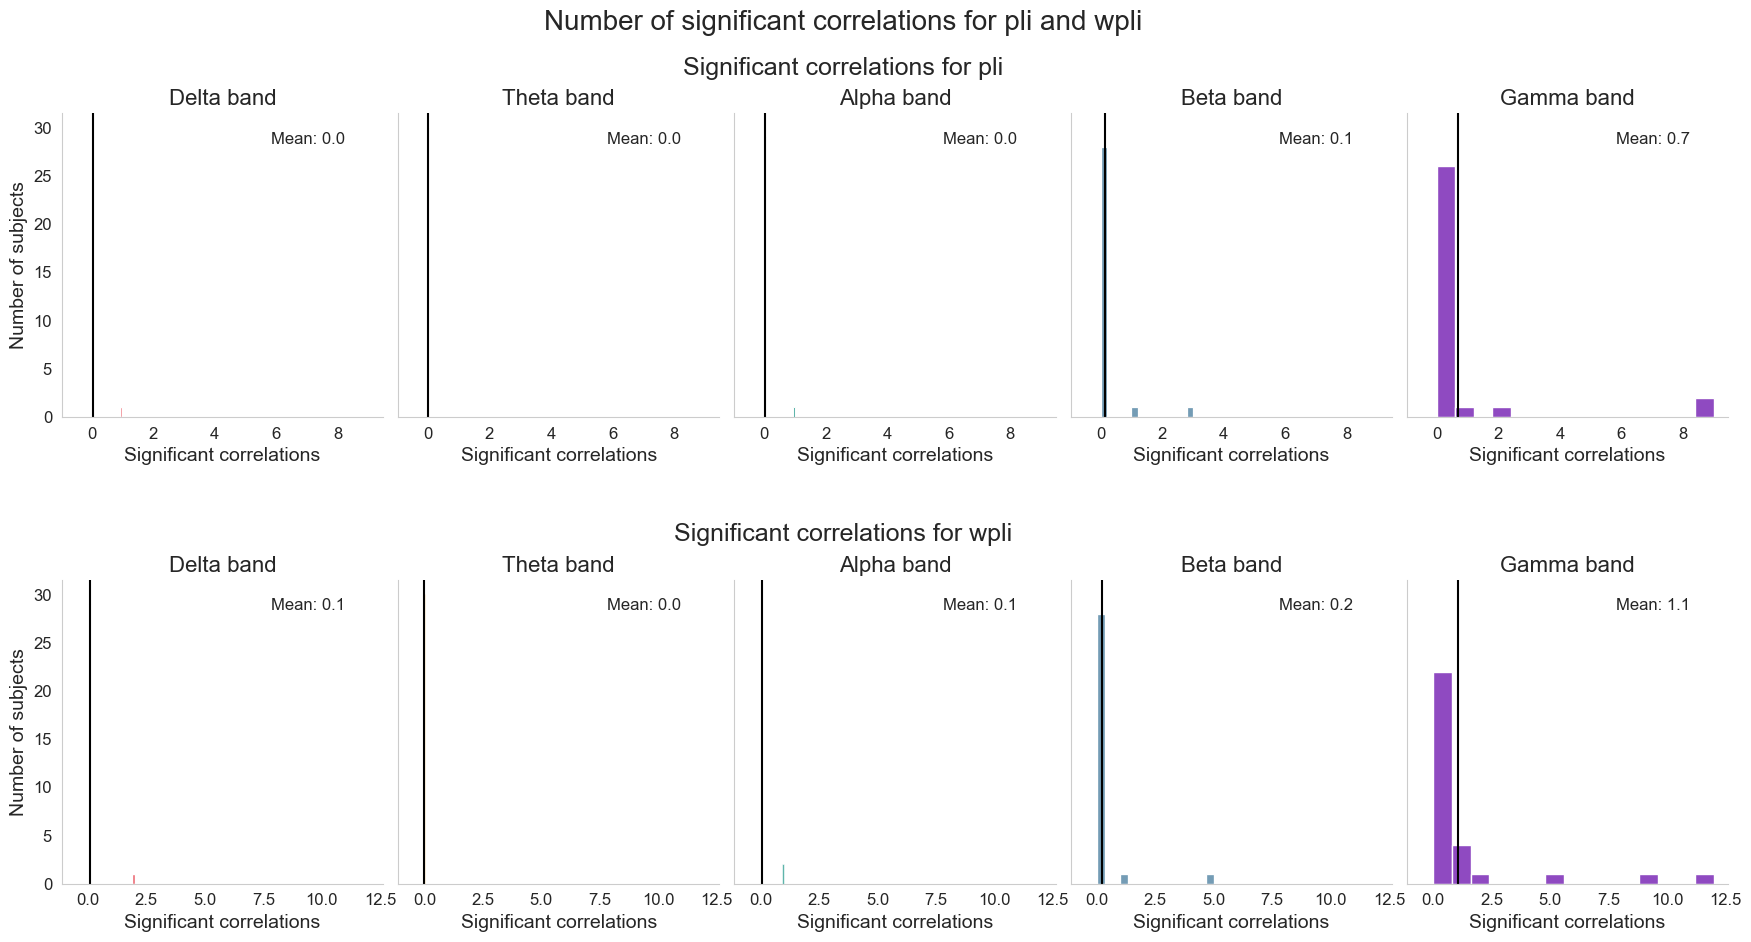

In [107]:
fig = plot_n_sig_correlations_multiple([n_sig_pli, n_sig_wpli, n_sig_icoh], features=["pli", "wpli"])
fig.savefig("results/number_of_significant_correlations_pli_wpli.png", bbox_inches='tight', dpi=300)

In [113]:
pac_data = np.load("PAC_results_all_subjects.npy", allow_pickle=True).item()


In [115]:
def n_sig_correlations_pac(pac_data, significance_level=0.05, bonferroni=60):
    freq_band_pairs = list(itertools.combinations(['delta', 'theta', 'alpha', 'beta', 'gamma'], 2))
    n_sig_correlations = {}
    relevant_pairs = {}
    for subject in pac_data.keys():
        n_sig_correlations[subject] = {}
        relevant_pairs[subject] = {}
        for freq_pair in freq_band_pairs:
            n_sig_correlations[subject][freq_pair] = 0
            relevant_pairs[subject][freq_pair] = []
            for ch_name, stats in pac_data[subject][freq_pair].items():
                if stats["p_value"] < (significance_level/bonferroni):
                    n_sig_correlations[subject][freq_pair] += 1
                    relevant_pairs[subject][freq_pair].append(ch_name)
           
     
    return n_sig_correlations, relevant_pairs

In [116]:
n_sig_pac, relevant_pairs = n_sig_correlations_pac(pac_data)

In [109]:
cfg = load_config()
relevant_channels = {pair: {} for pair in list(itertools.combinations(['delta', 'theta', 'alpha', 'beta', 'gamma'], 2))}
for subject in cfg.dataset.test_subject_indices:
    if subject in [92,102]:
        continue
    for pair in relevant_pairs[subject].keys():
        if len(relevant_pairs[subject][pair]) > 0:
            for ch in relevant_pairs[subject][pair]:
                if ch not in relevant_channels[pair]:
                    relevant_channels[pair][ch] = 1
                else:
                    relevant_channels[pair][ch] += 1
   



In [110]:
for pair in relevant_channels.keys():
    print(f"{pair} :{relevant_channels[pair]}")
    

('delta', 'theta') :{'C3': 1, 'C4': 1, 'O1': 2, 'O2': 1, 'F7': 1, 'T7': 1, 'T8': 1, 'P7': 1, 'P8': 1, 'FC1': 1, 'FC2': 1, 'CP6': 1, 'C1': 1, 'PO4': 1, 'P6': 1, 'FT7': 1, 'FT8': 1, 'PO7': 2, 'PO8': 1, 'CPz': 1, 'FC3': 1}
('delta', 'alpha') :{'F4': 2, 'C3': 2, 'C4': 1, 'O1': 1, 'O2': 1, 'P8': 1, 'CP2': 1, 'FC6': 1, 'CP5': 1, 'TP8': 1, 'PO7': 1, 'PO8': 1, 'Oz': 1, 'T7': 1, 'F6': 1, 'POz': 1}
('delta', 'beta') :{'O1': 1, 'O2': 1, 'FC2': 1, 'CP2': 1, 'CP3': 1, 'CP4': 1, 'PO8': 1, 'CPz': 1, 'POz': 1, 'PO7': 1, 'P2': 1, 'CP5': 1}
('delta', 'gamma') :{'O1': 3, 'O2': 1, 'P8': 1, 'C1': 1, 'CP3': 1, 'PO8': 1, 'CPz': 1, 'POz': 1, 'F7': 1, 'F6': 1}
('theta', 'alpha') :{'F4': 2, 'C3': 2, 'C4': 1, 'P3': 3, 'O1': 1, 'T8': 1, 'P7': 1, 'P8': 1, 'CP6': 1, 'F2': 1, 'C2': 1, 'P1': 3, 'AF3': 1, 'AF4': 1, 'FC3': 2, 'PO3': 2, 'P6': 2, 'AF7': 1, 'FT8': 1, 'TP7': 1, 'TP8': 1, 'PO7': 2, 'PO8': 1, 'POz': 1, 'Oz': 1, 'F5': 2, 'Fp2': 1, 'Fz': 1, 'FC1': 1, 'FC2': 1, 'CP1': 2, 'CP2': 1, 'CP5': 1, 'CP3': 1, 'C6': 1, '

In [141]:
def plot_n_sig_correlations_pac(data, freq_pairs=None, significance_level=0.05):
    sns.set_style("whitegrid")
    
    frequency_bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
    all_freq_pairs = list(itertools.combinations(frequency_bands, 2))
    
    # Filter frequency pairs if specified
    if freq_pairs is not None:
        plot_pairs = [pair for pair in all_freq_pairs if pair in freq_pairs]
    else:
        plot_pairs = all_freq_pairs
    
    # Define number of rows and columns for subplots
    n_pairs = len(plot_pairs)
    ncols = min(5, n_pairs)
    nrows = (n_pairs + ncols - 1) // ncols
    
    # Base colors for frequency bands (same as in plot_n_sig_correlations)
    base_colors = {
        'delta': '#E63946',  # Crimson red
        'theta': '#F9A826',  # Orange
        'alpha': '#2A9D8F',  # Teal
        'beta':  '#457B9D',  # Blue
        'gamma': '#6A0DAD',  # Purple
    }
    
    # Create mixed colors for pairs
    colors = {}
    for pair in all_freq_pairs:
        color1 = np.array(plt.cm.colors.to_rgb(base_colors[pair[0]]))
        color2 = np.array(plt.cm.colors.to_rgb(base_colors[pair[1]]))
        # Blend colors (60% first color, 40% second color)
        mixed_color = 0.6 * color1 + 0.4 * color2
        colors[pair] = plt.cm.colors.rgb2hex(mixed_color)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(18,4.5))
    if nrows == 1 and ncols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, freq_pair in enumerate(plot_pairs):
        if i < len(axes):
            # Extract values for this frequency pair
            subjects = list(data.keys())
            values = [data[subject][freq_pair] for subject in subjects]
            
            # Plot histogram with seaborn's histplot
            color = colors.get(freq_pair, '#1E88E5')  # Default color if not in dictionary
            sns.histplot(values, bins=10, color=color, kde=False, ax=axes[i])
            
            # Enhanced title with frequency band colors
            axes[i].set_title(f"{freq_pair[0].capitalize()} - {freq_pair[1].capitalize()}", 
                            fontsize=16, color='black')
            
            
            axes[i].set_xlabel("Number of significant correlations", fontsize=16)
            axes[i].set_ylabel("Number of subjects", fontsize=16)
            
            # Remove grid lines
            axes[i].grid(False)
            
            # Remove top and right spines
            axes[i].spines['top'].set_visible(False)
            axes[i].spines['right'].set_visible(False)
            
            # Add mean line with annotation
            mean_val = np.mean(values)
            axes[i].axvline(mean_val, color='black', linestyle='-', linewidth=1.5)
            axes[i].text(0.65, 0.85, f"Mean: {mean_val:.2f}", transform=axes[i].transAxes, 
                       fontsize=14, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            
            # Increase tick label font sizes
            axes[i].tick_params(axis='both', which='major', labelsize=15)
    
    # Hide unused subplots
    for i in range(len(plot_pairs), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    fig.suptitle("Number of significant correlations for PAC", 
                fontsize=20, y=1.05)
    
    return fig


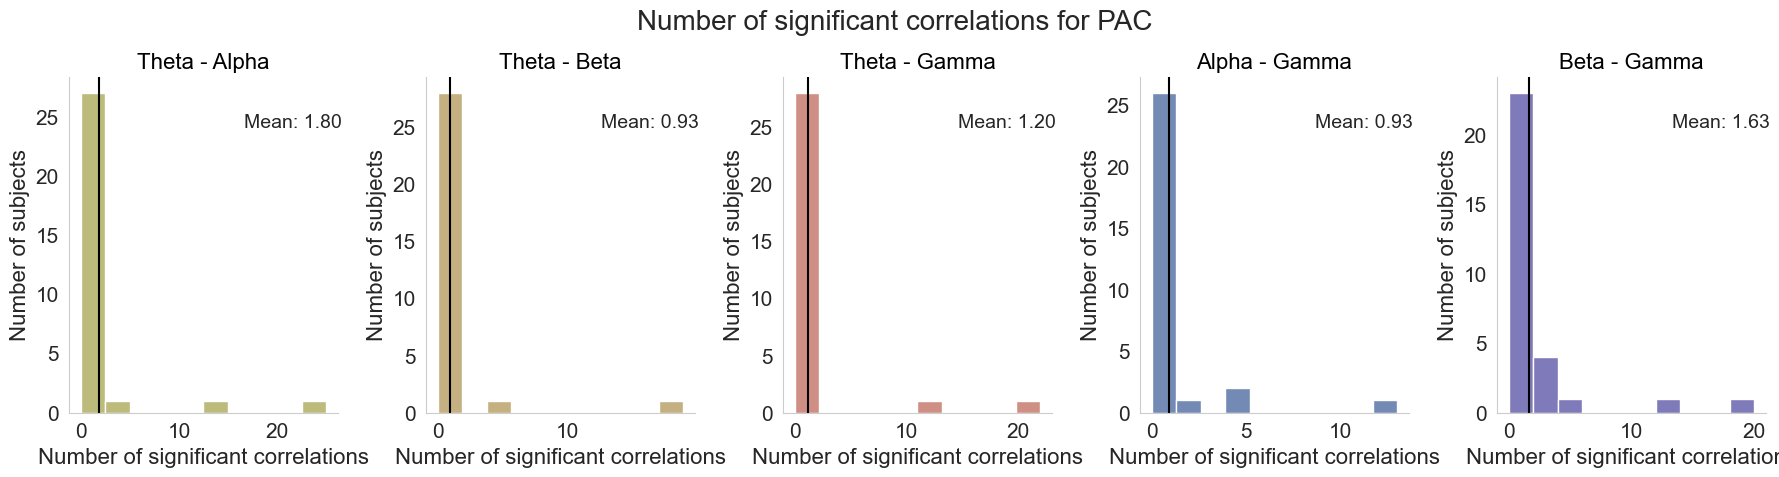

In [142]:
# for each subject there can be 60 significant correlations.
fig = plot_n_sig_correlations_pac(n_sig_pac, freq_pairs=[  ('theta', 'alpha'), ('theta', 'beta'), ('theta', 'gamma'),  ('alpha', 'gamma'), ('beta', 'gamma')])
fig.savefig("results/number_of_significant_correlations_pac.png", bbox_inches='tight', dpi=300)